# 07 Feature Engineering Assessment (E-27 to E-29)

**Data used:** the development set only (FR-009). The features are computed by the project's own transformers, `SemanticNAFiller` then `FeatureEngineer` (M4), so this notebook examines exactly what the pipeline will compute.  
**Question:** Q17 (DOC-02 §4.6): does each approved engineered feature show the expected relationship with log price?  
**Scope:** this is evidence only. Whether a feature is retained is decided in M7 by the cross-validation ablation (E-30, IN-04), not by the assessments below.

All computation lives in `house_price.features` and `house_price.eda.engineered` (FR-010).

In [1]:
from IPython.display import Image

from house_price.eda import EDAContext
from house_price.eda import engineered

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

## The engineered development set (first rows, engineered columns)

In [2]:
frame = engineered.engineered_frame(ctx)
frame[ctx.features.engineered].head()

,TotalSF,TotalBath,HouseAge,RemodAge,IsRemodeled,TotalPorchSF,HasPool,HasGarage,HasBsmt,HasFireplace,Has2ndFlr,GarageAge
0,2736.0,2.0,50,50,0,62,0,1,1,1,0,50.0
1,1778.0,1.0,49,49,0,120,0,1,1,0,0,49.0
2,2658.0,1.5,52,52,0,36,0,1,1,0,0,52.0
3,4220.0,3.5,42,42,0,0,0,1,1,1,0,42.0
4,2557.0,2.5,13,12,1,34,0,1,1,1,1,13.0


In [3]:
outputs = engineered.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-27_engineered_features',
 'E-28_binned_trends',
 'E-28_discrete_price_summary',
 'E-29_remodel_floor_audit',
 'E-28_engineered_continuous',
 'E-28_engineered_flags',
 'E-29_yearremodadd_distribution']

## E-27 Engineered feature table: definition, expected relationship (DOC-02 §10), observed correlation with log price, and the explicit assessment rule

In [4]:
outputs.tables["E-27_engineered_features"]

,feature,definition,expected_relationship,n,n_missing,pearson,spearman,assessment_rule,observed,hypothesis_supported
0,TotalSF,TotalBsmtSF + 1stFlrSF + 2ndFlrSF,"Strongly positive, near-linear; at least as st...",2340,0,0.819432,0.808035,Spearman > 0.5 and >= GrLivArea's,Spearman 0.808 (GrLivArea 0.719),True
1,TotalBath,FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*B...,"Positive and roughly stepwise, diminishing at ...",2340,0,0.674076,0.716803,Spearman > 0 and median rises across values wi...,Spearman 0.717; median log price rises across ...,False
2,HouseAge,YrSold - YearBuilt,"Negative, non-linear: steep drop over the firs...",2340,0,-0.608629,-0.674159,Spearman < 0 and the younger half of the decil...,Spearman -0.674; slope of binned medians per y...,True
3,RemodAge,YrSold - YearRemodAdd,Negative (§10.5),2340,0,-0.591858,-0.608913,Spearman < 0,Spearman -0.609,True
4,IsRemodeled,1 if YearRemodAdd != YearBuilt else 0,"Weak on its own, possibly mixed (§10.6)",2340,0,-0.089122,-0.089051,|Spearman| < 0.2,Spearman -0.089; median gap -0.073 (1090 remod...,True
5,TotalPorchSF,OpenPorchSF + EnclosedPorch + 3SsnPorch + Scre...,Mildly positive (§10.7),2340,0,0.186826,0.252839,0 < Spearman < 0.5,Spearman 0.253,True
6,HasPool,1 if PoolArea > 0 else 0,Uncertain: too rare for a reliable estimate (§...,2340,0,0.046145,0.041583,fewer than 1% of rows have a pool,9 pools (0.38% of rows); median gap +0.356,True
7,HasGarage,1 if GarageType != 'None' else 0,Clearly positive: garage-less houses are marke...,2340,0,0.318390,0.301667,median log price gap > 0.2,median log price gap +0.509 (2206 of 2340 with...,True
8,HasBsmt,1 if TotalBsmtSF > 0 else 0,Positive (§10.8),2340,0,0.215453,0.197192,median log price gap > 0,median log price gap +0.471 (2273 of 2340 with...,True
9,HasFireplace,1 if Fireplaces > 0 else 0,Positive (§10.8),2340,0,0.516972,0.533776,median log price gap > 0,median log price gap +0.361 (1196 of 2340 with...,True


## E-28 Log price against each engineered feature (continuous features with decile medians; presence flags as box plots)

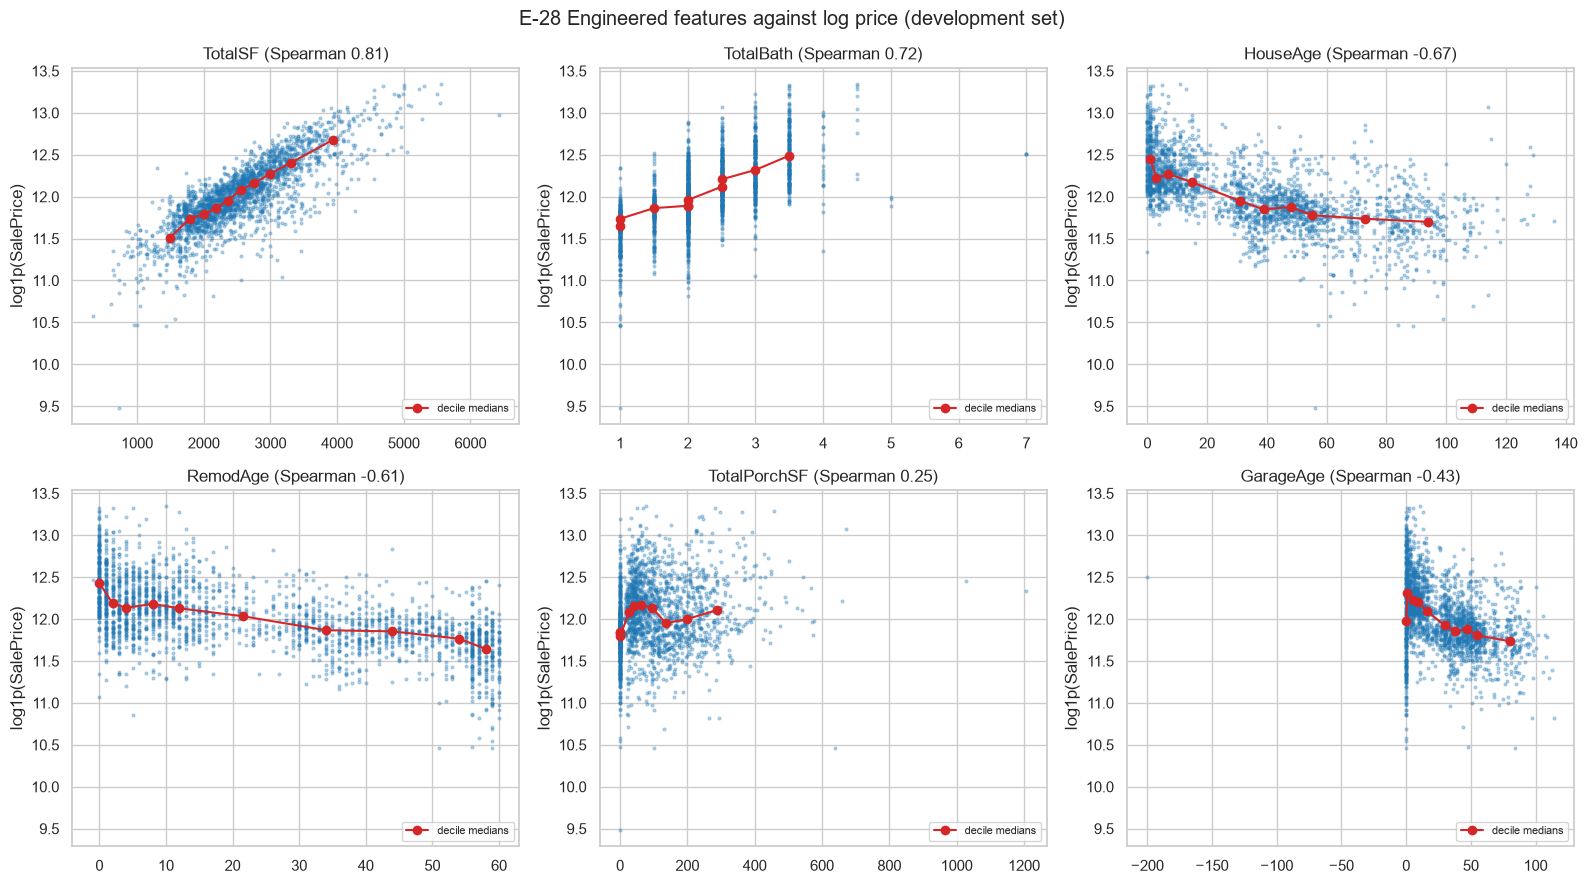

In [5]:
Image(filename=outputs.figures["E-28_engineered_continuous"])

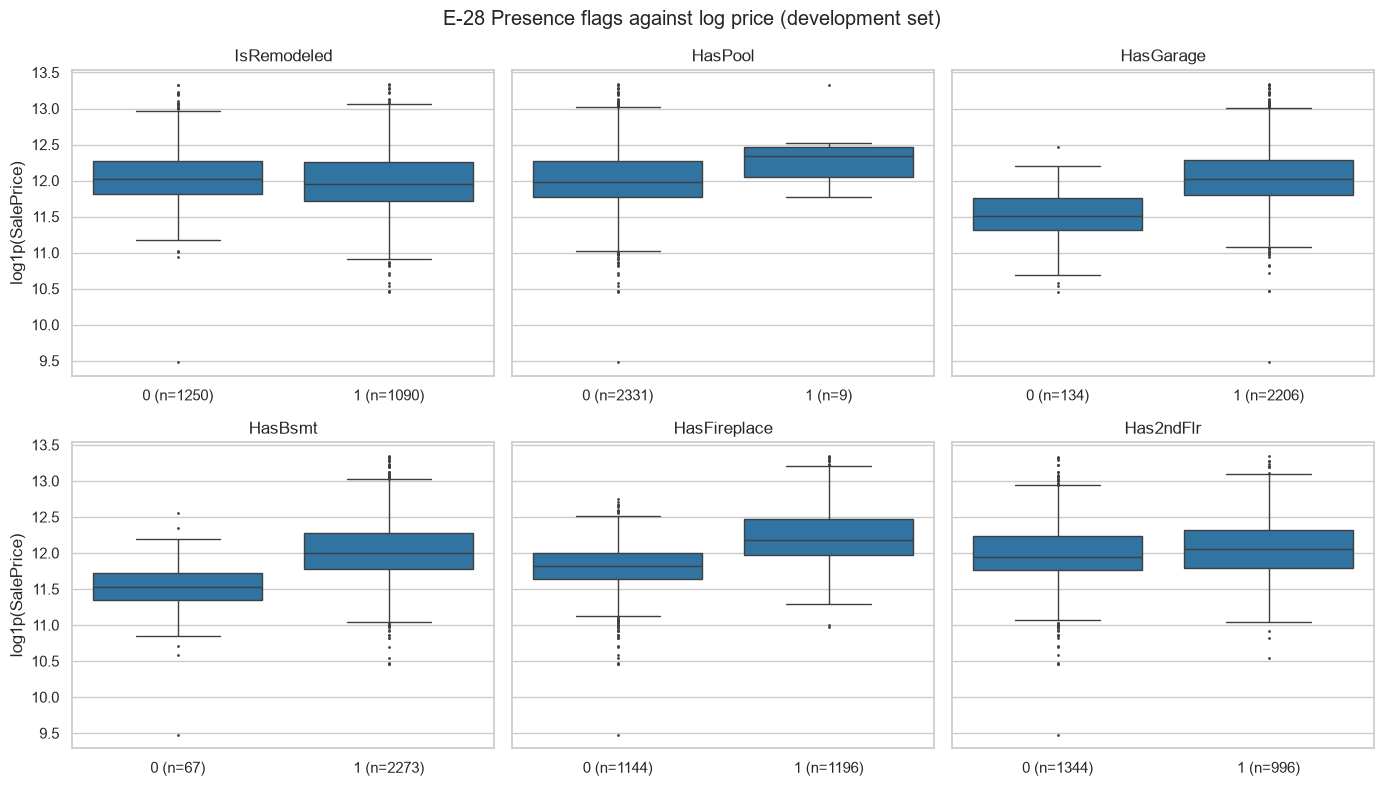

In [6]:
Image(filename=outputs.figures["E-28_engineered_flags"])

In [7]:
outputs.tables["E-28_discrete_price_summary"]

,feature,value,n,median_log_price
0,IsRemodeled,0.0,1250,12.023657
1,IsRemodeled,1.0,1090,11.950864
2,HasPool,0.0,2331,11.982935
3,HasPool,1.0,9,12.339296
4,HasGarage,0.0,134,11.510431
5,HasGarage,1.0,2206,12.019749
6,HasBsmt,0.0,67,11.530775
7,HasBsmt,1.0,2273,12.001512
8,HasFireplace,0.0,1144,11.814886
9,HasFireplace,1.0,1196,12.176136


In [8]:
outputs.tables["E-28_binned_trends"]

,feature,bin,n,x_median,median_log_price
0,TotalSF,0,234,1489.5,11.507410
1,TotalSF,1,234,1786.0,11.736077
2,TotalSF,2,234,2007.0,11.794345
3,TotalSF,3,234,2184.0,11.865787
4,TotalSF,4,234,2357.0,11.951187
5,TotalSF,5,234,2553.5,12.081039
6,TotalSF,6,234,2752.0,12.160034
7,TotalSF,7,234,2988.0,12.269050
8,TotalSF,8,234,3304.0,12.403693
9,TotalSF,9,234,3933.0,12.676079


## E-29 Remodel-date audit: rows at the 1950 `YearRemodAdd` floor and the effect on `RemodAge` and `IsRemodeled`

In [9]:
outputs.tables["E-29_remodel_floor_audit"]

,metric,value,note
0,development_rows,2340.0,rows analysed
1,remodel_year_below_floor,0.0,YearRemodAdd < 1950 (0 confirms the floor)
2,remodel_year_at_floor,297.0,YearRemodAdd = 1950
3,floor_rows_built_before_1950,279.0,"remodel year may be the recording floor, not a..."
4,floor_rows_built_in_1950,18.0,genuinely unremodeled 1950 houses
5,houses_built_before_1950,516.0,
6,pct_pre1950_houses_at_floor,54.1,share of pre-1950 houses whose remodel year is...
7,floor_rows_flagged_remodeled,279.0,IsRemodeled = 1 because 1950 != YearBuilt; may...
8,pct_of_remodeled_flags_from_floor,25.6,share of all IsRemodeled = 1 rows that sit at ...
9,floor_rows_remodage_min,56.0,RemodAge = YrSold - 1950 for every floor row


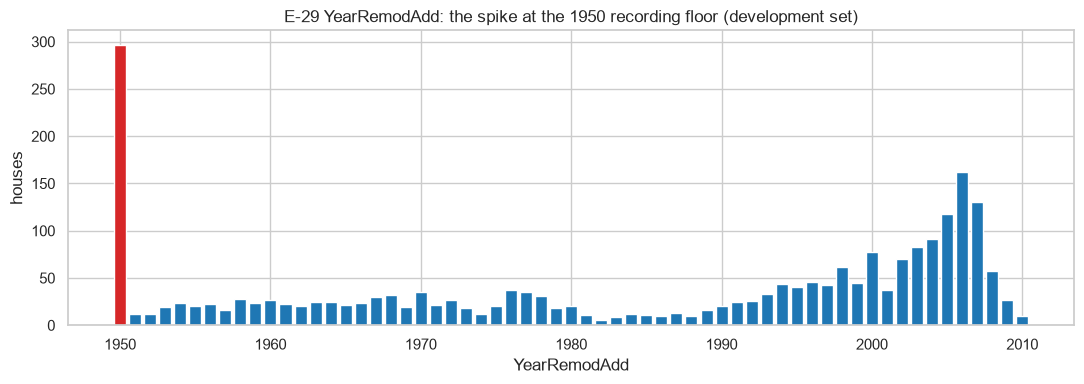

In [10]:
Image(filename=outputs.figures["E-29_yearremodadd_distribution"])